# RE608 Legged Robot - Week 7: Gait Planning
## Program Studi Teknologi Rekayasa Robotika - Politeknik Negeri Batam

Notebook ini akan mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*) dan memvisualisasikan diagram *gait* untuk robot berkaki. Kita akan membandingkan berbagai jenis *gait* untuk *quadruped* (Trot, Crawl) dan merancang *Tripod Gait* untuk *Hexapod*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib

# Konfigurasi Google Colab untuk menampilkan animasi matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

print("Environment siap!")

Environment siap!


### 1. Definisi Parameter Gait & Quadruped Scheduler
Sebuah siklus *gait* ditentukan oleh beberapa parameter utama:
- **Stride Period (T):** Waktu yang dibutuhkan untuk menyelesaikan satu siklus penuh.
- **Duty Factor ($\beta$):** Rasio waktu kaki berada di tanah (*stance phase*) dibandingkan dengan total periode siklus.
- **Phase Offset ($\phi$):** Perbedaan waktu mulai siklus antar kaki.

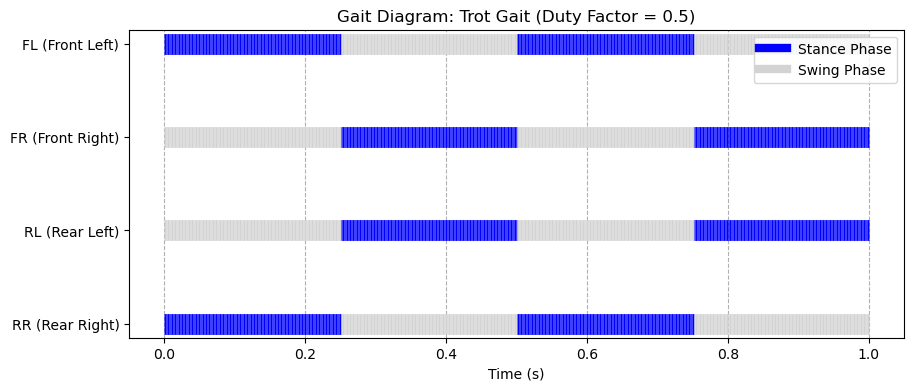

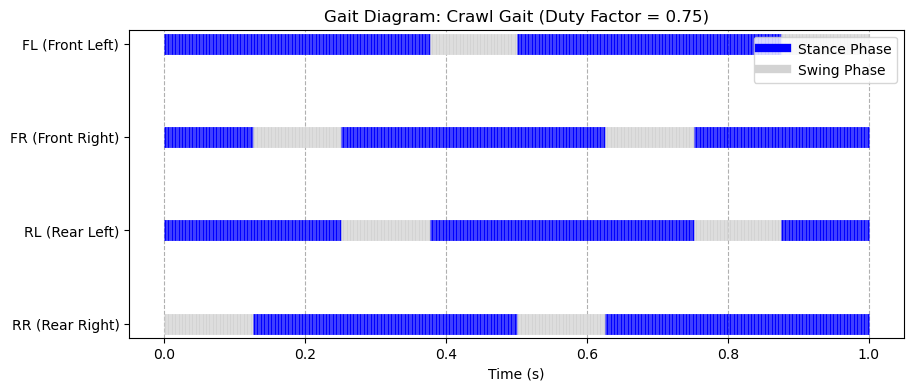

In [12]:
class QuadrupedGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)', 'RL (Rear Left)', 'RR (Rear Right)']

    def get_phase(self, t, offset):
        # Menghitung fase dari 0.0 hingga 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500) # Plot untuk 2 siklus

        fig, ax = plt.subplots(figsize=(10, 4))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            # Stance (kaki di tanah) = 1, Swing (kaki di udara) = 0
            stance = np.where(phases < duty_factor, 1, 0)

            # Plotting diagram Gantt
            for t_idx in range(len(time_steps)-1):
                if stance[t_idx] == 1:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='blue', lw=15, solid_capstyle='butt')
                else:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='lightgray', lw=15, solid_capstyle='butt')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        # Legend custom
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        plt.show()

# Inisialisasi scheduler
scheduler = QuadrupedGaitScheduler(T=0.5)

# 1. Trot Gait: Pasangan diagonal bergerak bersamaan
trot_offsets = [0.0, 0.5, 0.5, 0.0]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# 2. Crawl Gait: Gerak bergantian satu per satu, sangat stabil statis
crawl_offsets = [0.0, 0.5, 0.25, 0.75] # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')

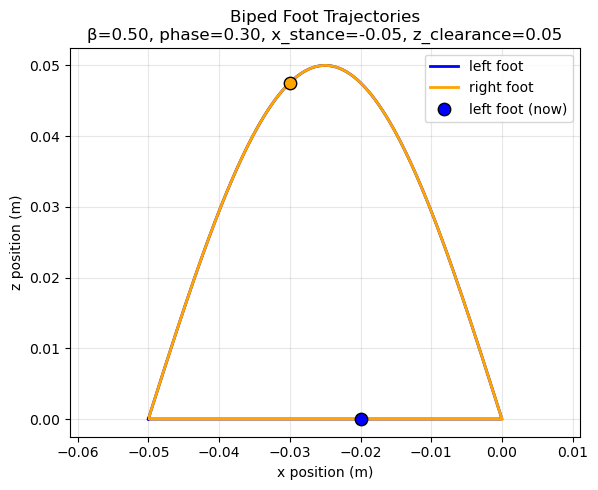

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """Return desired (x, z) foot position for leg phase in [0,1)."""
    if phase < beta:  # stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# ----- Editable parameters -----
beta = 0.5          # duty factor (stance fraction)
phase = 0.3         # current phase (0..1) to show instantaneous foot positions
x_stance = -0.05    # x position during stance (m)
x_lift = 0.0        # x position at lift-off / touch-down (m)
z_ground = 0.0      # ground height (m)
z_clearance = 0.05  # max foot height during swing (m)
# --------------------------------

T = 1.0  # period of one gait cycle (s)
t = np.linspace(0, T, 400)
phases = t / T  # 0 to 1

# Offsets for left and right foot (opposite phase)
offsets = {'left': 0.0, 'right': 0.5}

plt.figure(figsize=(6,5))
for leg, offset in offsets.items():
    xs, zs = [], []
    for ph in phases:
        x, z = foot_position_cmd((ph + offset) % 1.0,
                                 beta, x_stance, x_lift,
                                 z_ground, z_clearance)
        xs.append(x); zs.append(z)
    color = 'blue' if leg == 'left' else 'orange'
    plt.plot(xs, zs, label=f'{leg} foot', color=color, linewidth=2)

# Instantaneous positions at current phase
cur_xs, cur_zs = [], []
for leg, offset in offsets.items():
    ph_cur = (phase + offset) % 1.0
    x_cur, z_cur = foot_position_cmd(ph_cur, beta,
                                     x_stance, x_lift,
                                     z_ground, z_clearance)
    cur_xs.append(x_cur); cur_zs.append(z_cur)
    color = 'blue' if leg == 'left' else 'orange'
    plt.scatter([x_cur], [z_cur], color=color, s=80, zorder=5,
                edgecolors='k', label=f'{leg} foot (now)' if leg == 'left' else None)

plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.title('Biped Foot Trajectories\n'
          f'β={beta:.2f}, phase={phase:.2f}, x_stance={x_stance:.2f}, '
          f'z_clearance={z_clearance:.2f}')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Assignment: Hexapod Tripod Gait Design

Sesuai materi perkuliahan minggu ini, hexapod dapat menggunakan *tripod gait* di mana 3 kaki membentuk fondasi segitiga yang stabil, secara bergantian (alternating triangles).

**Tugas Praktikum:**
1. Modifikasi kelas/fungsi di atas agar mampu menangani 6 kaki (L1, L2, L3, R1, R2, R3).
2. Buat matriks `offsets` dan tentukan *duty factor* yang tepat untuk *Tripod Gait*.
3. Plot diagram *gait*-nya dan verifikasi kelayakan stabilitasnya.
4. Tuliskan analisis Anda mengenai perbedaan stabilitas antara *Trot Quadruped* dengan *Tripod Hexapod* di sel *markdown* bawah.

---
**Catatan Implementasi Teknis Lanjutan:**
Nantinya saat Anda mengintegrasikan luaran *gait scheduler* ini ke simulasi skrip *forward/inverse kinematics* Anda, pastikan *coxa* dipaksa beroperasi konstan pada bidang XY. Selain itu, Anda harus menghapus keberadaan titik koordinat *base* dari matriks simulasi kakinya. Hal ini akan mencegah perhitungan matriks singular dan mempercepat konvergensi algoritma IK saat transisi fase *stance* ke *swing*.

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def foot_position_cmd(
    phase,
    beta,
    x_stance=-0.05,
    x_lift=0.0,
    z_ground=0.0,
    z_clearance=0.05
):

    if phase < beta:
        t = phase / beta

        x = x_stance + (x_lift - x_stance) * t
        z = z_ground

    else:
        t = (phase - beta) / (1.0 - beta)

        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)

    return x, z

In [ ]:
#inisialisasi hexapod gait scheduler
class HexapodGaitScheduler:

    def __init__(self, T=1.0):
        # menentukan periode gait
        self.T = T
        #menentukan kaki hexapod
        self.legs = [
            'L1','L2','L3',
            'R1','R2','R3'
        ]

    def get_phase(self, t, offset):

        return ((t / self.T) + offset) % 1.0

    #plot gait diagram
    def plot_gait_diagram(
        self,
        duty_factor,
        offsets,
        x_stance,
        x_lift,
        z_ground,
        z_clearance
    ):

        time_steps = np.linspace(
            0,
            2*self.T,
            500
        )

        fig, (ax1, ax2) = plt.subplots(
            1,
            2,
            figsize=(15,5)
        )

        # ==========================
        # gantt tipod gait
        # ==========================

        for i, (leg, offset) in enumerate(
            zip(self.legs, offsets)
        ):

            phases = self.get_phase(
                time_steps,
                offset
            )

            stance = np.where(
                phases < duty_factor,
                1,
                0
            )

            y_pos = 5 - i

            for t_idx in range(len(time_steps)-1):

                color = (
                    'blue'
                    if stance[t_idx]
                    else 'lightgray'
                )
                #menampilkan diagram gait
                ax1.plot(
                    [time_steps[t_idx],
                     time_steps[t_idx+1]],
                    [y_pos, y_pos],
                    color=color,
                    lw=12,
                    solid_capstyle='butt'
                )

        ax1.set_yticks(range(6))
        ax1.set_yticklabels(self.legs[::-1])

        ax1.set_xlabel("Time (s)")
        ax1.set_title("Tripod Gait Diagram")
        ax1.grid(axis='x', linestyle='--')

        custom_lines = [
            plt.Line2D([0], [0], color='blue', lw=6),
            plt.Line2D([0], [0], color='lightgray', lw=6)
        ]

        ax1.legend(
            custom_lines,
            ['Stance', 'Swing']
        )

        # ==========================
        # langkah kaki
        # ==========================

        t_cycle = np.linspace(
            0,
            self.T,
            200
        )

        leg_colors = [
            'red',
            'green',
            'blue',
            'orange',
            'purple',
            'gray'
        ]

        current_phase = 0.30

        for i, (leg, offset) in enumerate(
            zip(self.legs, offsets)
        ):

            xs = []
            zs = []

            visual_offset = i * 0.005

            for t in t_cycle:

                phase = self.get_phase(
                    t,
                    offset
                )

                x, z = foot_position_cmd(
                    phase,
                    duty_factor,
                    x_stance,
                    x_lift,
                    z_ground,
                    z_clearance
                )

                xs.append(x)
                zs.append(z + visual_offset)

            ax2.plot(
                xs,
                zs,
                color=leg_colors[i],
                linewidth=2,
                alpha=0.5
            )

            phase_now = (
                current_phase + offset
            ) % 1.0

            x_now, z_now = foot_position_cmd(
                phase_now,
                duty_factor,
                x_stance,
                x_lift,
                z_ground,
                z_clearance
            )

            ax2.scatter(
                x_now,
                z_now + visual_offset,
                color=leg_colors[i],
                s=80,
                edgecolors='k',
                label=leg
            )

        ax2.set_xlabel("X (m)")
        ax2.set_ylabel("Z (m)")
        ax2.set_title("Hexapod Foot Trajectory")
        ax2.grid(True)

        ax2.legend(
            loc='upper center',
            bbox_to_anchor=(0.5, -0.15),
            ncol=3
        )

        plt.tight_layout()
        plt.show()

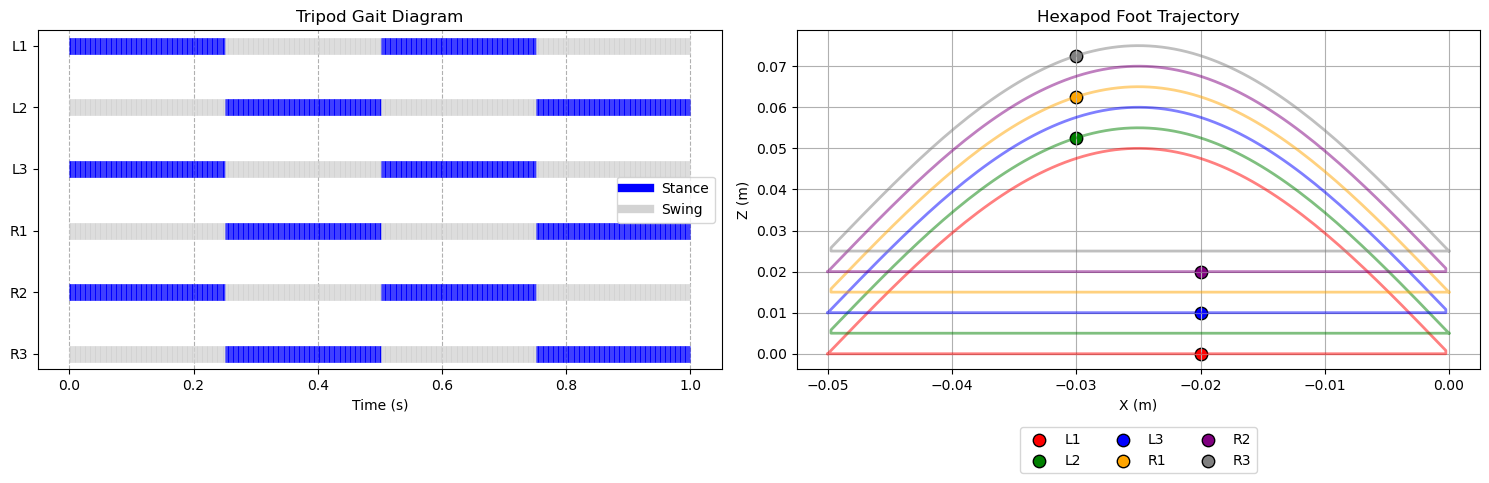

In [34]:
#menjalankan tripod gait
scheduler = HexapodGaitScheduler(T=0.5)

tripod_offsets = [

    0.0,  # L1
    0.5,  # L2

    0.0,  # L3
    0.5,  # R1

    0.0,  # R2
    0.5   # R3
]

tripod_duty_factor = 0.5

scheduler.plot_gait_diagram(
    duty_factor=tripod_duty_factor,
    offsets=tripod_offsets,
    x_stance=-0.05,
    x_lift=0.0,
    z_ground=0.0,
    z_clearance=0.05
)

## Analisis Perbandingan Stabilitas Trot Quadruped dan Tripod Hexapod

### 1. Trot Quadruped

Pada gait trot, pasangan kaki diagonal bergerak secara bersamaan. Pada suatu waktu hanya terdapat dua kaki yang menopang tubuh robot, yaitu satu kaki depan dan satu kaki belakang yang berada pada sisi berlawanan.

Keuntungan gait ini adalah pergerakan robot menjadi lebih cepat dan efisien. Namun, stabilitasnya relatif lebih rendah karena area tumpuan hanya berupa garis yang menghubungkan dua kaki penyangga. Apabila pusat massa robot keluar dari garis tersebut, robot berpotensi kehilangan keseimbangan.

### 2. Tripod Hexapod

Pada tripod gait, enam kaki dibagi menjadi dua kelompok:

- Tripod A = L1, R2, L3
- Tripod B = R1, L2, R3

Ketika Tripod A berada pada fase stance, Tripod B berada pada fase swing. Setelah itu kedua kelompok bertukar fase secara bergantian.

Pada setiap saat terdapat tiga kaki yang menyentuh tanah sehingga membentuk area penyangga berbentuk segitiga. Area segitiga ini memberikan stabilitas yang lebih baik dibandingkan garis tumpuan pada trot quadruped.

### 3. Kesimpulan

Tripod Hexapod memiliki stabilitas yang lebih tinggi dibandingkan Trot Quadruped karena selalu memiliki tiga titik kontak yang membentuk segitiga penyangga. Trot Quadruped lebih cepat dan sederhana, tetapi lebih rentan terhadap kehilangan keseimbangan ketika robot bergerak pada permukaan yang tidak rata. Oleh karena itu, tripod gait lebih cocok digunakan pada robot hexapod yang ditujukan untuk navigasi medan kasar dan aplikasi search and rescue.

seperti iniii buatnya di nootbook